In [ ]:
library(CellChat)
library(patchwork)
library(Seurat)
library(SeuratData)
library(purrr)
library(dplyr)
library(stringr)

In [3]:
packageVersion('CellChat')

[1] ‘2.1.2’

In [ ]:
library(DT)

In [3]:
options(stringsAsFactors = FALSE)

In [7]:
GCA_subset <- readRDS("GCA_obj_subset_excludecells3.Rdata") 

In [8]:
Idents(object = GCA_subset) <- "celltype"

In [9]:
GCA_subset@meta.data$celltype %>% table()

.
         Bcell         CD4+ T       CD8+ Low         CD8+ T DendriticCells 
          6547           3878           1543           3678            776 
   Endothelial     Epi_normal      Epi_tumor    Fibroblasts   MacrophageM1 
          4138           1575           5131           3623            445 
  MacrophageM2       Mastcell      Monocytes     Musclecell    Neutrophils 
          1197           1169           1125           1021            969 
        NKcell       Pericyte         Plasma   Regulatory T 
          1035            679           6692           1691 

In [10]:
celltypes <- c('Bcell','CD4+ T','CD8+ T','DendriticCells','CD8+ Low','Endothelial','Epi_tumor','Fibroblasts','MacrophageM1',
              'MacrophageM2','Mastcell','Monocytes','Neutrophils','NKcell','Pericyte','Proliferating T','Regulatory T','Plasma')

In [11]:
GCA_subset2 <- subset(x = GCA_subset, subset = celltype %in% celltypes)

In [12]:
lownames <- c("SC008","SC005","SC027")
highnames <- c("SC032","SC017","SC015","SC031")

In [13]:
subset(x = GCA_subset2, sample %in% highnames) -> GCA_subset_high

In [14]:
subset(x = GCA_subset2, sample %in% lownames) -> GCA_subset_low

In [15]:
GCA_subset_high@meta.data %>% colnames() -> colnames

In [16]:
colnames[4] <- "samples"

In [17]:
colnames(GCA_subset_high@meta.data) <- colnames
colnames(GCA_subset_low@meta.data) <- colnames

In [18]:
GCA_subset_high

An object of class Seurat 
36601 features across 23025 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.cca, umap

In [19]:
GCA_subset_low

An object of class Seurat 
36601 features across 21291 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 3 dimensional reductions calculated: pca, integrated.cca, umap

In [20]:
#LayerData(GCA_subset_high, assay = "RNA", layer = "data") -> high.input
#LayerData(GCA_subset_low, assay = "RNA", layer = "data") -> low.input

In [21]:
highlabels <- Idents(GCA_subset_high)
lowlabels <- Idents(GCA_subset_low)

In [22]:
Idents(GCA_subset_high) %>% unique()

[1] Neutrophils    Regulatory T   Endothelial    Plasma         Mastcell      
 [6] CD8+ T         Fibroblasts    MacrophageM2   NKcell         Epi_tumor     
[11] Bcell          Monocytes      CD4+ T         CD8+ Low       DendriticCells
[16] Pericyte       MacrophageM1  
17 Levels: CD4+ T Endothelial Plasma Regulatory T NKcell Neutrophils ... Pericyte

In [23]:
Idents(GCA_subset_low) %>% unique()

[1] CD4+ T         Endothelial    Plasma         Regulatory T   NKcell        
 [6] Neutrophils    Bcell          CD8+ Low       MacrophageM2   Epi_tumor     
[11] Monocytes      CD8+ T         MacrophageM1   Mastcell       DendriticCells
[16] Fibroblasts    Pericyte      
17 Levels: CD4+ T Endothelial Plasma Regulatory T NKcell Neutrophils ... Pericyte

In [24]:
meta_high <- data.frame(labels = highlabels, row.names = names(highlabels)) # create a dataframe of the cell labels
meta_low <- data.frame(labels = lowlabels, row.names = names(lowlabels)) # create a dataframe of the cell labels

In [25]:
GCA_subset_high$subcelltype  %>% unique()

[1] MyeloidCells Tcells       Endothelial  Plasma       Mastcell    
[6] Fibroblasts  Epi_tumor    Bcell        Pericyte    
11 Levels: Tcells Endothelial Plasma MyeloidCells Bcell ... Pericyte

## Part I: Data input & processing and initialization of CellChat object

### Create a CellChat object

In [26]:
cellChat_high <- createCellChat(object = GCA_subset_high, group.by = "ident", assay = "RNA")
cellChat_low <- createCellChat(object = GCA_subset_low, group.by = "ident", assay = "RNA")

[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 


Warning message in createCellChat(object = GCA_subset_high, group.by = "ident", :
“The 'meta$samples' is not a factor. We now force it as a factor!”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  CD4+ T, Endothelial, Plasma, Regulatory T, NKcell, Neutrophils, Bcell, CD8+ Low, MacrophageM2, Epi_tumor, Monocytes, CD8+ T, MacrophageM1, Mastcell, DendriticCells, Fibroblasts, Pericyte 
[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 


Warning message in createCellChat(object = GCA_subset_low, group.by = "ident", assay = "RNA"):
“The 'meta$samples' is not a factor. We now force it as a factor!”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  CD4+ T, Endothelial, Plasma, Regulatory T, NKcell, Neutrophils, Bcell, CD8+ Low, MacrophageM2, Epi_tumor, Monocytes, CD8+ T, MacrophageM1, Mastcell, DendriticCells, Fibroblasts, Pericyte 


### Set the ligand-receptor interaction database

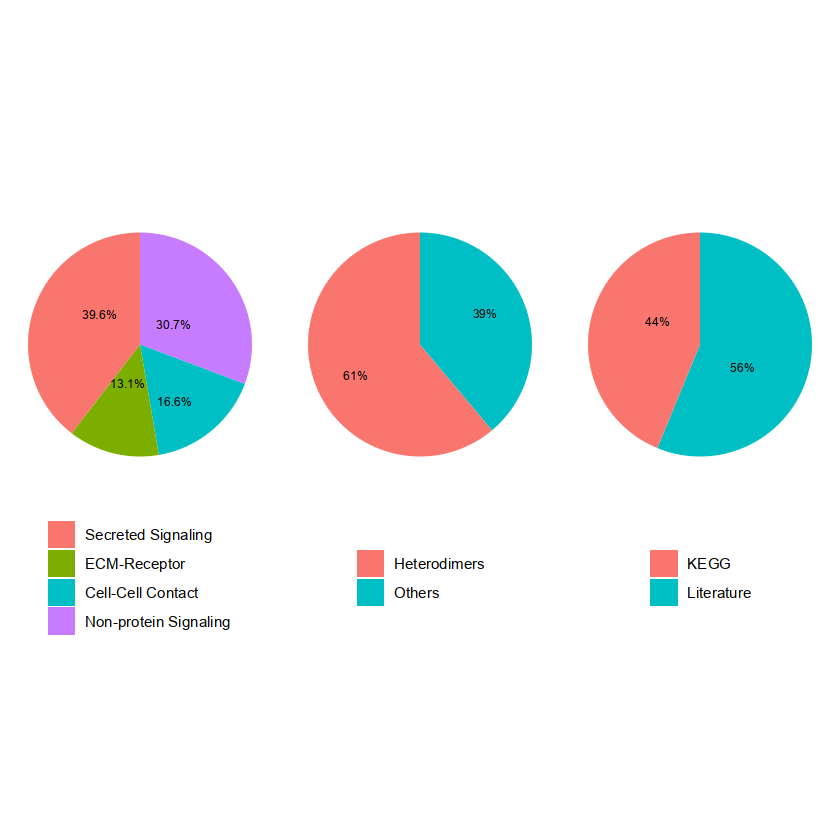

In [27]:
CellChatDB <- CellChatDB.human # use CellChatDB.mouse if running on mouse data
showDatabaseCategory(CellChatDB)

In [28]:
#CellChatDB$interaction[,c(1:11)]  %>% write.table(.,file = 'allcellchat.txt',quote = F,sep = "\t",row.names = F)

In [29]:
CellChatDB.use <- subsetDB(CellChatDB, search = "Secreted Signaling", key = "annotation") # use Secreted Signaling

In [30]:
#CellChatDB.use <- subsetDB(CellChatDB, search = "Cell-Cell Contact", key = "annotation") # use Secreted Signaling

In [31]:
#CellChatDB.use$interaction  %>% write.table(.,file = 'allcellchat.txt',quote = F,sep = "\t",row.names = F)

In [32]:
#FGL1 = c('FGL1_LAG3','FGL1','FGL1','LAG3','','','','','PMID: 30580966','Cell-Cell Contact','FGL1_LAG3','FALSE','FGL1',
 #        'fibrinogen family','Cell membrane','','','true','LAG3','LAG3','','','','','','','','')

In [346]:
#SIRPA = c('SIRPA_CD47','SIRPA','SIRPA','CD47','','','','','PMID: 30580966','Cell-Cell Contact','SIRPA_CD47','FALSE','SIRPA',
 #        'fibrinogen family','Cell membrane','','','true','CD47','CD47','','','','','','','','')

In [347]:
#TIGIT = c('TIGIT_PVR','TIGIT','TIGIT','PVR','','','','','PMID: 30580966','Cell-Cell Contact','TIGIT_PVR','FALSE','TIGIT',
 #        'fibrinogen family','Cell membrane','','','true','PVR','PVR','','','','','','','','')

In [348]:
#CellChatDB.use$interaction  %>%  colnames() -> names

In [349]:
#FGL1_2 <- setNames(as.data.frame(t(FGL1), stringsAsFactors = FALSE), names)

In [350]:
#SIRPA_2 <- setNames(as.data.frame(t(SIRPA), stringsAsFactors = FALSE), names)

In [351]:
#TIGIT_2 <- setNames(as.data.frame(t(TIGIT), stringsAsFactors = FALSE), names)

In [352]:
#rownames(FGL1_2) <- 'FGL1_LAG3'
#rownames(SIRPA_2) <- 'SIRPA_CD47'
#rownames(TIGIT_2) <- 'TIGIT_PVR'

In [353]:
#CellChatDB.use$interaction  %>% rbind(FGL1_2,SIRPA_2,TIGIT_2) -> CellChatDB.use$interaction 

In [354]:
#immunecheckpoints <- c("CD80","CD86","CD40LG","ICOSLG","CD276","CD160","FGL1","CD274","PDCD1LG2",'SIRPA','TIGIT')

In [355]:
#CellChatDB.use$interaction  %>% filter(ligand %in% immunecheckpoints)  -> CellChatDB.use$interaction

In [356]:
#write.table(x = CellChatDB.use$interaction ,file = "CellChatDB.use.cellcontact.txt",sep="\t",quote = F)

In [33]:
cellChat_high@DB <- CellChatDB.use
cellChat_low@DB <- CellChatDB.use

### Preprocessing the expression data for cell-cell communication analysis


In [34]:
# subset the expression data of signaling genes for saving computation cost
cellChat_high <- subsetData(cellChat_high) # This step is necessary even if using the whole database
# subset the expression data of signaling genes for saving computation cost
cellChat_low <- subsetData(cellChat_low)  # This step is necessary even if using the whole database

In [35]:
future::plan("multisession", workers = 4) # do parallel
cellChat_high <- identifyOverExpressedGenes(cellChat_high)
cellChat_low <- identifyOverExpressedGenes(cellChat_low)

In [36]:
cellChat_high <- identifyOverExpressedInteractions(cellChat_high)
cellChat_low <- identifyOverExpressedInteractions(cellChat_low)

The number of highly variable ligand-receptor pairs used for signaling inference is 1171 
The number of highly variable ligand-receptor pairs used for signaling inference is 1162 


## Part II: Inference of cell-cell communication network


### Compute the communication probability and infer cellular communication network

In [37]:
cellChat_high <- computeCommunProb(cellChat_high,type = "triMean")

triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2024-06-14 16:06:20]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2024-06-14 16:38:39]"


In [38]:
cellChat_low <- computeCommunProb(cellChat_low,type = "triMean")

triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2024-06-14 16:38:47]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2024-06-14 16:48:21]"


In [39]:
cellChat_high <- filterCommunication(cellChat_high, min.cells = 10)
cellChat_low <- filterCommunication(cellChat_low, min.cells = 10)

In [40]:
cellChat_high <- computeCommunProbPathway(cellChat_high)
cellChat_low <- computeCommunProbPathway(cellChat_low)

In [41]:
Highdf.net <- subsetCommunication(cellChat_high)

In [42]:
#Highdf.net[,c('ligand','receptor')]  %>% unique()

In [43]:
Lowdf.net <- subsetCommunication(cellChat_low)

### Calculate the aggregated cell-cell communication network

In [44]:
library(ggpubr)

In [45]:
cellChat_high <- aggregateNet(cellChat_high)
cellChat_low <- aggregateNet(cellChat_low)

In [46]:
groupSize_high <- as.numeric(table(cellChat_high@idents))
groupSize_low <- as.numeric(table(cellChat_low@idents))

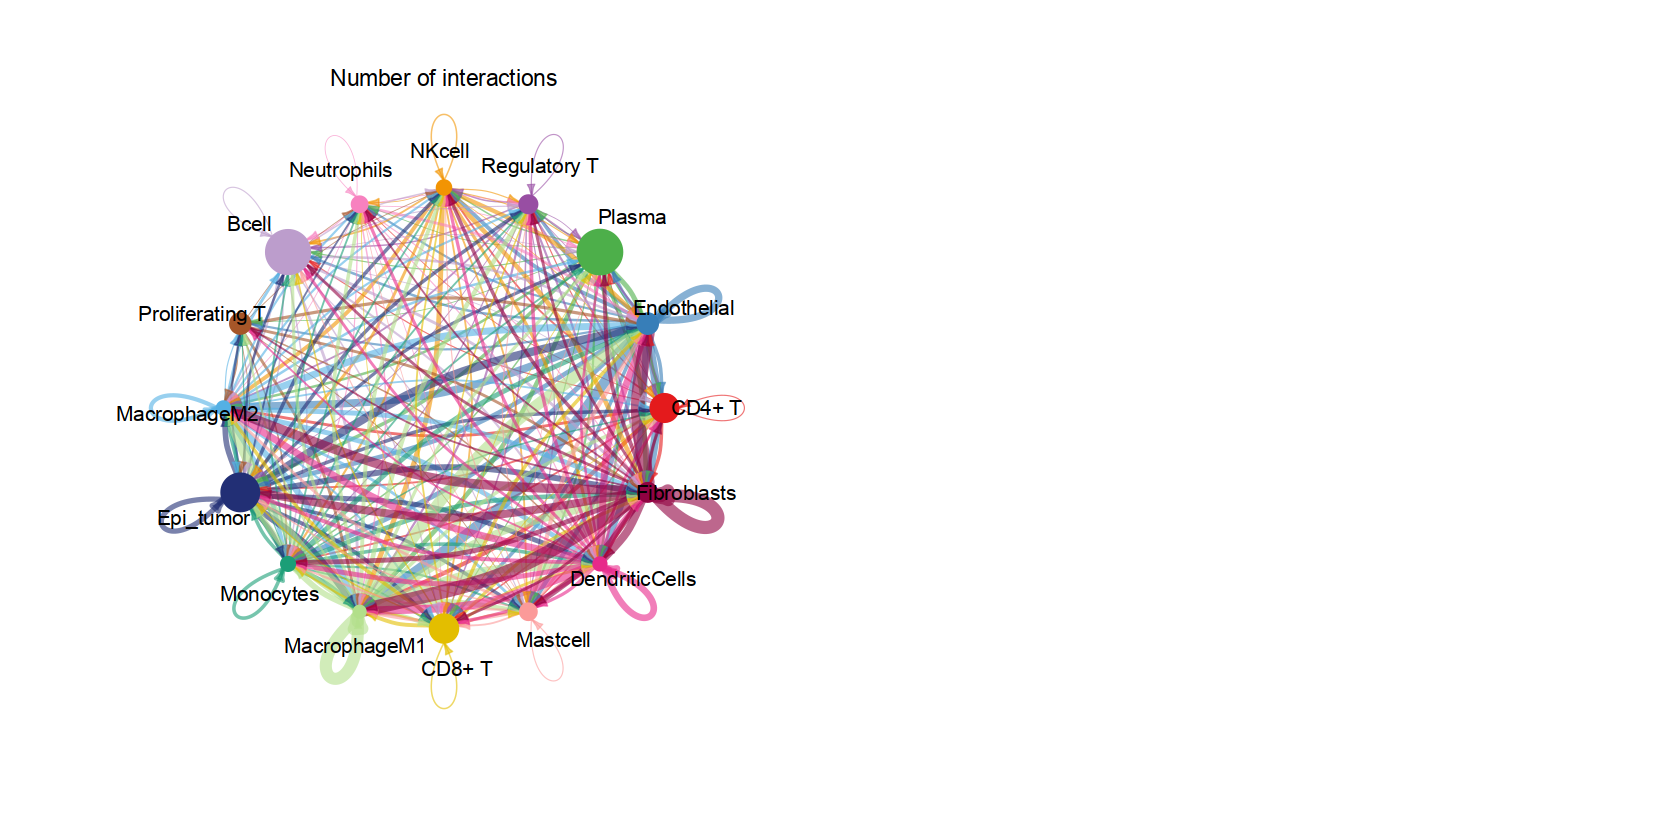

In [ ]:
par(mfrow = c(1,2), xpd=TRUE)
options(repr.plot.height=7,repr.plot.width=14)
#pdf(file ="High_cellchat_overrall.pdf" ,width =6 ,height =6)
p_high1 <- netVisual_circle(cellChat_high@net$count, vertex.weight = groupSize_high, weight.scale = T,
                 label.edge= F, title.name = "Number of interactions")
#p_high2 <- netVisual_circle(cellChat_high@net$weight, vertex.weight = groupSize_high, weight.scale = T, 
         #        label.edge= F, title.name = "Interaction weights/strength")
#dev.off()

In [20]:
groupSize <- as.numeric(table(cellChat_high@idents)) # number of cells in each cell group
mat_h <- cellChat_high@net$weight
#par(mfrow = c(3,4), xpd=TRUE)
pdf(file ="High_cellchat_all.pdf" ,width =6 ,height =6)
for (i in 1:nrow(mat_h)) {
  mat2_h <- matrix(0, nrow = nrow(mat_h), ncol = ncol(mat_h), dimnames = dimnames(mat_h))
  mat2_h[i, ] <- mat_h[i, ]
  netVisual_circle(mat2_h, vertex.weight = groupSize, weight.scale = T, edge.weight.max = max(mat_h)/2
                   ,
                   title.name = rownames(mat_h)[i])
}
dev.off()

png 
  2

In [21]:
groupSize <- as.numeric(table(cellChat_low@idents)) # number of cells in each cell group
mat_l <- cellChat_low@net$weight
pdf(file ="Low_cellchat_all.pdf" ,width =6 ,height =6)
#par(mfrow = c(3,4), xpd=TRUE)
for (i in 1:nrow(mat_l)) {
  mat2_l <- matrix(0, nrow = nrow(mat_l), ncol = ncol(mat_l), dimnames = dimnames(mat_l))
  mat2_l[i, ] <- mat_l[i, ]
  netVisual_circle(mat2_l, vertex.weight = groupSize, weight.scale = T, edge.weight.max = max(mat_l)/2,
                   title.name = rownames(mat_l)[i])
}
dev.off()

png 
  2

In [ ]:
par(mfrow = c(1,2), xpd=TRUE)
#pdf(file ="low_cellchat_overrall.pdf" ,width =6 ,height =6 )
#p_low1 <- netVisual_circle(cellChat_low@net$count, vertex.weight = groupSize_low, weight.scale = T,
         #        label.edge= F, title.name = "Number of interactions")
#p_low2 <- netVisual_circle(cellChat_low@net$weight, vertex.weight = groupSize_low, weight.scale = T, 
          #       label.edge= F, title.name = "Interaction weights/strength")
#dev.off()

In [ ]:
mat_high <- cellChat_high@net$weight
mat_low <- cellChat_low@net$weight

In [130]:
par(mfrow = c(3,4), xpd=TRUE)

In [ ]:
for (i in 1:nrow(mat_high)) {
  mat_high2 <- matrix(0, nrow = nrow(mat_high), ncol = ncol(mat_high), dimnames = dimnames(mat_high))
  mat_high2[i, ] <- mat_high[i, ]
  netVisual_circle(mat_high2, vertex.weight = groupSize_high, weight.scale = T, 
                   edge.weight.max = max(mat_high2), title.name = rownames(mat_high2)[i])
}

In [ ]:
for (i in 1:nrow(mat_low)) {
  mat_low2 <- matrix(0, nrow = nrow(mat_low), ncol = ncol(mat_low), dimnames = dimnames(mat_low))
  mat_low2[i, ] <- mat_low[i, ]
  netVisual_circle(mat_low2, vertex.weight = groupSize_low, weight.scale = T, 
                   edge.weight.max = max(mat_low2), title.name = rownames(mat_low2)[i]) }

## Part III: Visualization of cell-cell communication network

### Visualize each signaling pathway using Hierarchy plot, Circle plot or Chord diagram

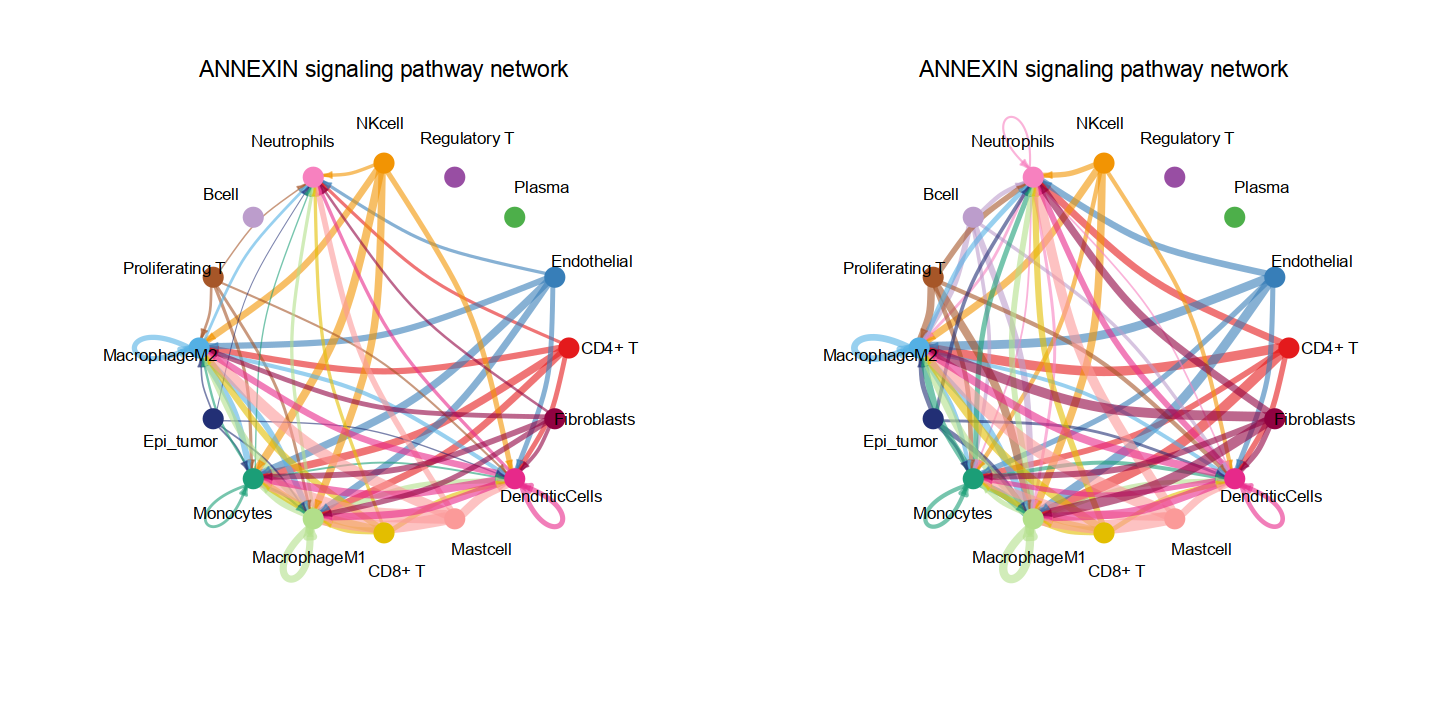

In [58]:
pathways.show <- c("ANNEXIN") 
par(mfrow = c(1,2), xpd=TRUE)
# Hierarchy plot
# Here we define `vertex.receive` so that the left portion of the hierarchy plot shows signaling to fibroblast and the right portion shows signaling to immune cells 
#vertex.receiver = seq(1,4) # a numeric vector. 
options(repr.plot.height=6,repr.plot.width=12)
ph = netVisual_aggregate(cellChat_high, signaling = pathways.show, layout = "circle",show.legend =TRUE ,legend.pos.x=1)
pl = netVisual_aggregate(cellChat_low, signaling = pathways.show, layout = "circle",show.legend =TRUE,legend.pos.x = 50,legend.pos.y = 20, )# Circle plot

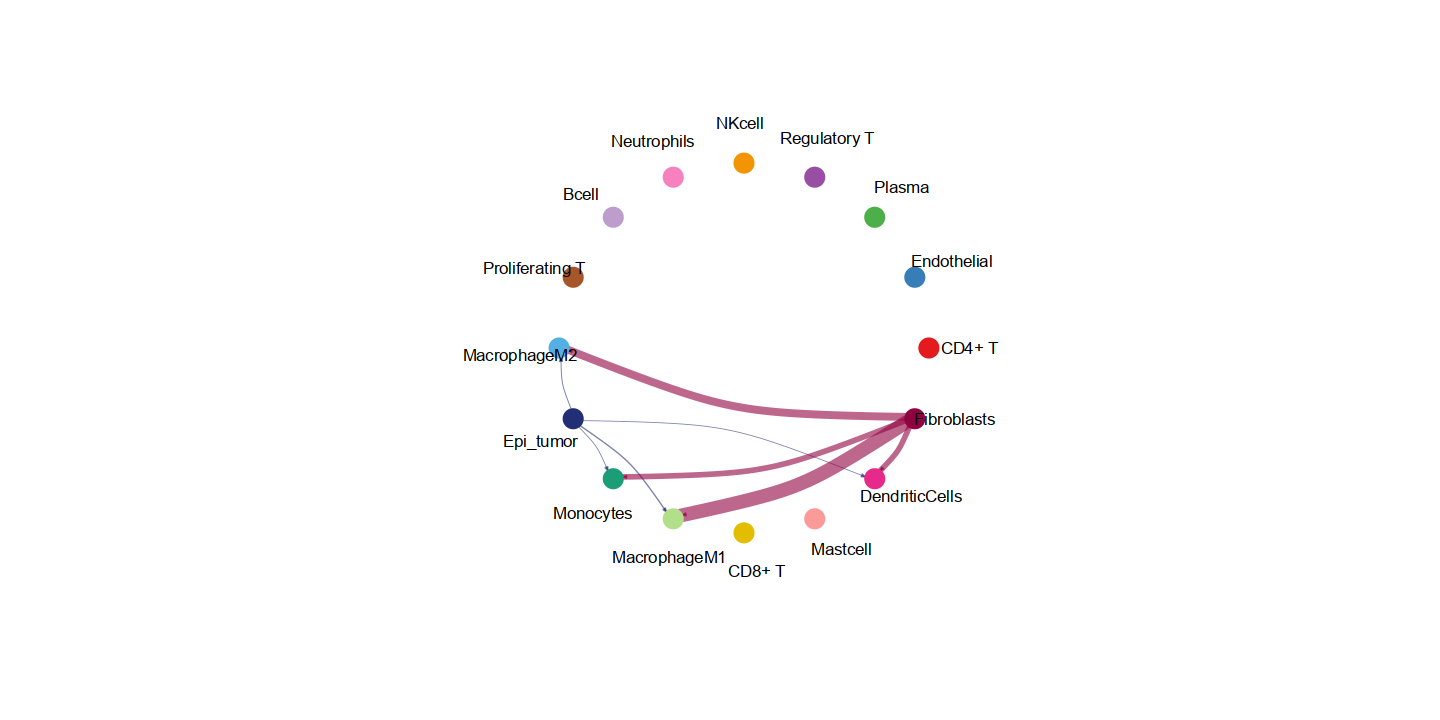

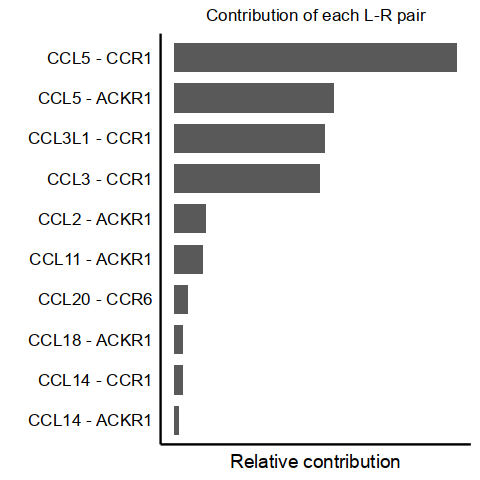

In [ ]:
options(repr.plot.height=4,repr.plot.width=4)
netAnalysis_contribution(cellChat_high, signaling = pathways.show)

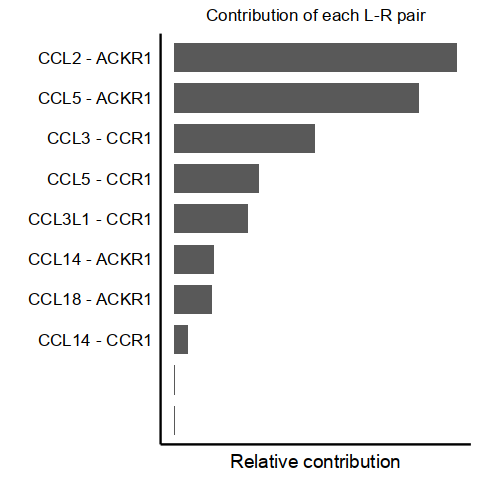

In [ ]:
options(repr.plot.height=4,repr.plot.width=4)
netAnalysis_contribution(cellChat_low, signaling = pathways.show)

## Part IV: Systems analysis of cell-cell communication network

### (A) Compute and visualize the network centrality scores  

In [47]:
cellChat_high <- netAnalysis_computeCentrality(cellChat_high, slot.name = "netP") # the slot 'netP' means the inferred intercellular communication network of signaling pathways
# Visualize the computed centrality scores using heatmap, allowing ready identification of major signaling roles of cell groups

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-2’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "igno

In [48]:
    cellChat_low <- netAnalysis_computeCentrality(cellChat_low, slot.name = "netP") # the slot 'netP' means the inferred intercellular communication network of signaling pathways
# Visualize the computed centrality scores using heatmap, allowing ready identification of major signaling roles of cell groups

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_sapply-2’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "igno

In [44]:
options(repr.plot.height=6,repr.plot.width=8)
#netAnalysis_signalingRole_network(cellChat_high, signaling = pathways.show, width = 16, height = 7, font.size = 10)

In [45]:
options(repr.plot.height=6,repr.plot.width=8)
#netAnalysis_signalingRole_network(cellChat_low, signaling = pathways.show, width = 16, height = 7, font.size = 10)

### B) Visualize dominant senders (sources) and receivers (targets) in a 2D space

In [46]:
gg1 <- netAnalysis_signalingRole_scatter(cellChat_high)
#> Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways
# Signaling role analysis on the cell-cell communication networks of interest
gg2 <- netAnalysis_signalingRole_scatter(cellChat_low)

#> Signaling role analysis on the cell-cell communication network from user's input

Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways

Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.
ℹ The deprecated feature was likely used in the CellChat package.
  Please report the issue to the authors.”
Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways



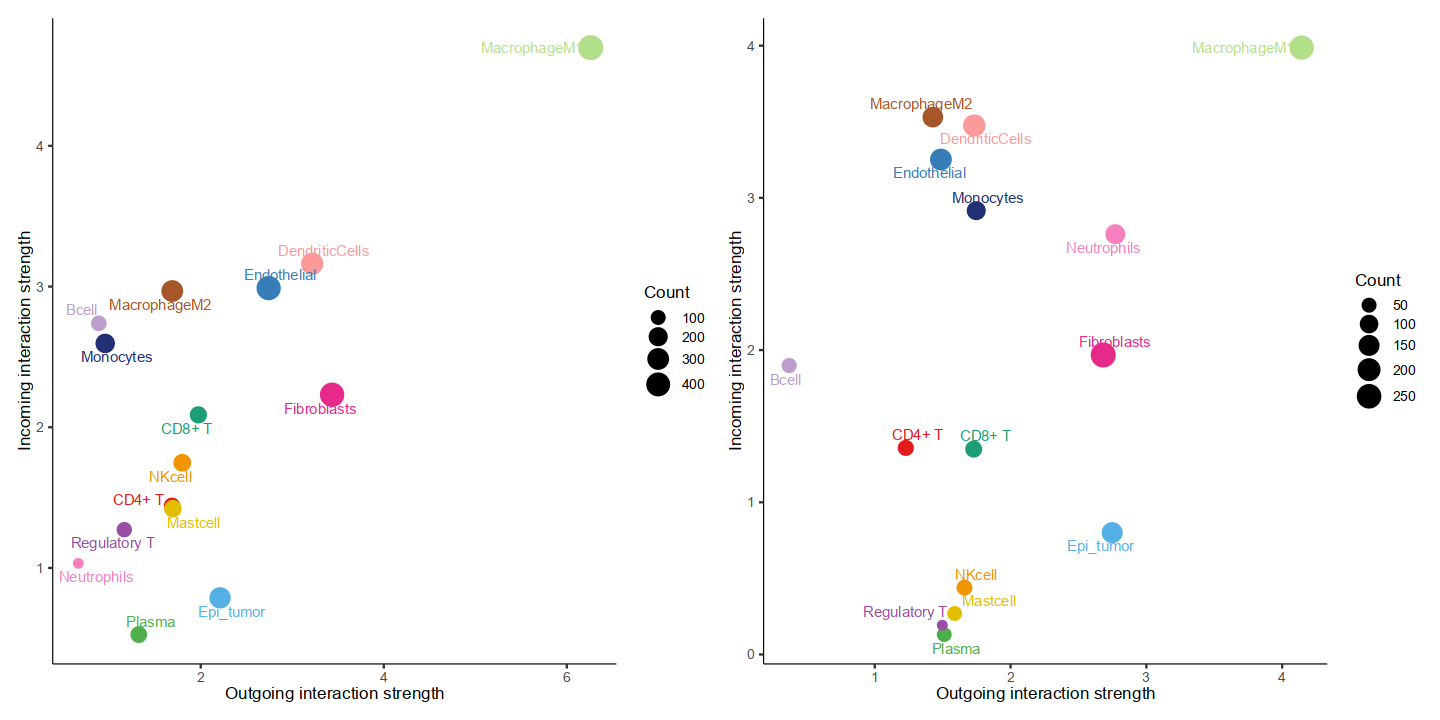

In [47]:
options(repr.plot.height=6,repr.plot.width=12)
gg1 + gg2

### (C) Identify signals contributing the most to outgoing or incoming signaling of certain cell groups

In [ ]:
ht1 <- netAnalysis_signalingRole_heatmap(cellChat_high, pattern = "outgoing",width = 10,height = 14)
ht2 <- netAnalysis_signalingRole_heatmap(cellChat_high, pattern = "incoming",width = 10,height = 14)

In [ ]:
options(repr.plot.height=8,repr.plot.width=12)
ht1

In [ ]:
options(repr.plot.height=8,repr.plot.width=12)
ht2

In [ ]:
#saveRDS(object = cellChat_high,file = "cellChat_high_cellcellcontact2.Rds")
#saveRDS(object = cellChat_low,file = "cellChat_low_cellcellcontact2.Rds")

In [49]:
saveRDS(object = cellChat_high,file = "cellChat_high_SecretSig3.Rds")
saveRDS(object = cellChat_low,file = "cellChat_low_SecretSig3.Rds")

In [3]:
cellChat_high <- readRDS(file = "cellChat_high_SecretSig3.Rds")
cellChat_low <- readRDS(file = "cellChat_low_SecretSig3.Rds")

In [2]:
#cellChat_high <- readRDS(file = "cellChat_high.Rds")
#cellChat_low <- readRDS(file = "cellChat_low.Rds")

In [ ]:
#pdf(file = "SPP1_Low_specific_signaling_M2.pdf",width = 8,height = 8)
p_endo_ccl_high <- netVisual_chord_gene(cellChat_high, sources.use = 12, targets.use = c(1:11),
                                        slot.name = 'net',net = net.up, lab.cex = 0.8, small.gap = 3.5,                                        
                     title.name = paste0("Specific signaling in ", names(object.list)[1]))
#dev.off()